📥 Chargement SPY (01/01/2000 - 31/12/2024)...

📈 Estimation GARCH(1,1)...
✅ GARCH(1,1) convergé. ω=0.000004, α=0.1002, β=0.8800
✅ Train: 3760 | Val: 1254 | Test: 1254 jours

🧠 Entraînement LSTM (features: returns + σ_GARCH)...
Epoch 1/15
117/117 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - loss: 5.2259e-05 - val_loss: 1.6027e-05
Epoch 2/15
117/117 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 4.2854e-05 - val_loss: 7.2551e-05
Epoch 3/15
117/117 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 2.9322e-05 - val_loss: 8.4653e-05
Epoch 4/15
117/117 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 2.7465e-05 - val_loss: 1.5424e-04
Epoch 5/15
117/117 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 2.5430e-05 - val_loss: 2.5042e-04
Epoch 6/15
117/117 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 2.6196e-05 - val_loss: 1.1016e-04
Epoch 7/15
117/117 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 2.1664e-05 - val_loss: 1.1902e-04
Epoch 8/15
117/117 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 1.8635e-05 - val_loss: 9.0154e-05
Epoch 9/15
117/117

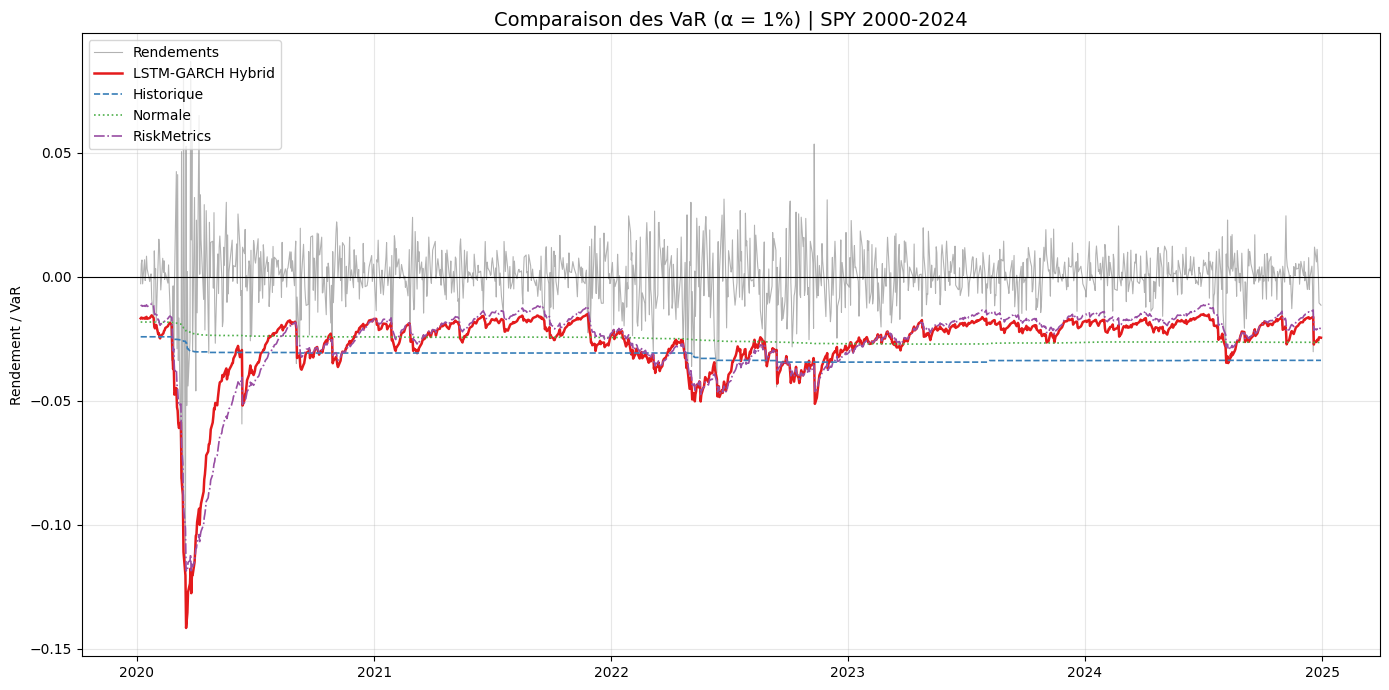


💾 Résultats sauvegardés dans : /content/VaR_LSTM_GARCH_Hybrid.pkl


In [3]:
# ==============================================================================
# Value-at-Risk_Hybrid_LSTM_GARCH.py : Estimation + Backtesting
# Fusion LSTM + GARCH(1,1) vs Alternatives | Google Colab Ready
# ==============================================================================
!pip install -q yfinance tensorflow pandas numpy scipy matplotlib arch

import numpy as np
import pandas as pd
import yfinance as yf
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from arch import arch_model
from scipy.stats import norm, chi2
import matplotlib.pyplot as plt
import pickle
import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)
tf.random.set_seed(42)

# ==============================================================================
# 1. Chargement & Préparation des données
# ==============================================================================
print("📥 Chargement SPY (01/01/2000 - 31/12/2024)...")
raw = yf.download('SPY', start='2000-01-01', end='2024-12-31', progress=False)
if isinstance(raw.columns, pd.MultiIndex):
    raw.columns = [' '.join(c).strip() for c in raw.columns]
price_col = next((c for c in raw.columns if 'Close' in c), 'Close')
df = raw[[price_col]].copy().rename(columns={price_col: 'price'})
df.index = pd.to_datetime(df.index)
if df.index.tz is not None: df.index = df.index.tz_localize(None)
df = df.loc[(df.index >= '2000-01-01') & (df.index <= '2024-12-31')]

df['returns'] = np.log(df['price'] / df['price'].shift(1))
df = df.dropna()
df['vol_20'] = df['returns'].rolling(window=20).std()
df = df.dropna()

n = len(df)

# ==============================================================================
# 2. GARCH(1,1) & Génération de σ sur TOUTE la série (AVANT le split)
# ==============================================================================
print("\n📈 Estimation GARCH(1,1)...")
# On définit les bornes de split maintenant, mais on ne slice PAS encore df
split_train = int(0.6 * n)
split_val   = int(0.8 * n)

# Fit GARCH uniquement sur la partie train
garch = arch_model(df['returns'].iloc[:split_train].values, vol='Garch', p=1, q=1, dist='Normal')
garch_fit = garch.fit(disp='off')

# Extraction des paramètres
omega = garch_fit.params['omega']
alpha_param = garch_fit.params['alpha[1]']
beta  = garch_fit.params['beta[1]']

# Génération récursive de σ_GARCH sur l'intégralité de df
sigma_garch = np.full(n, np.nan)
garch_train_vol = garch_fit.conditional_volatility / 100.0  # arch renvoie en %
sigma_garch[:len(garch_train_vol)] = garch_train_vol

# Récursion pour Val & Test
sigma_garch[split_train] = garch_train_vol[-1]
for i in range(split_train + 1, n):
    r_prev = df['returns'].iloc[i-1]
    sigma_prev = sigma_garch[i-1]
    sigma_garch[i] = np.sqrt(omega + alpha_param * r_prev**2 + beta * sigma_prev**2)

df['sigma_garch'] = sigma_garch
print(f"✅ GARCH(1,1) convergé. ω={omega:.6f}, α={alpha_param:.4f}, β={beta:.4f}")

# ==============================================================================
# 3. SPLIT MAINTENANT (σ_GARCH est bien présent dans df)
# ==============================================================================
df_train = df.iloc[:split_train].copy()
df_val   = df.iloc[split_train:split_val].copy()
df_test  = df.iloc[split_val:].copy()

print(f"✅ Train: {len(df_train)} | Val: {len(df_val)} | Test: {len(df_test)} jours")

# ==============================================================================
# 4. Préparation & Entraînement LSTM
# ==============================================================================
print("\n🧠 Entraînement LSTM (features: returns + σ_GARCH)...")
lookback = 30
features = ['returns', 'sigma_garch']

def create_sequences(data_df, features, target_col, lb):
    X, y = [], []
    for i in range(lb, len(data_df)):
        X.append(data_df[features].iloc[i-lb:i].values)
        y.append(data_df[target_col].iloc[i])
    return np.array(X), np.array(y)

X_train, y_train = create_sequences(df_train, features, 'vol_20', lookback)

# Val sequences
df_val_seq = df.iloc[split_train - lookback : split_val]
X_val, y_val = create_sequences(df_val_seq, features, 'vol_20', lookback)

model = Sequential([
    LSTM(64, return_sequences=False, input_shape=(lookback, 2)),
    Dropout(0.2),
    Dense(32, activation='relu'),
    Dense(1)
])
model.compile(optimizer=tf.keras.optimizers.Adam(1e-3), loss='mse')
model.fit(X_train, y_train, epochs=15, batch_size=32, validation_data=(X_val, y_val), verbose=1)

# Prédictions Val
sigma_lstm_val = model.predict(X_val, verbose=0).flatten()
val_start_idx = split_val - len(sigma_lstm_val)
val_dates = df.index[val_start_idx:split_val]

# ==============================================================================
# 5. Fusion optimale (ω·σ_GARCH + (1-ω)·σ_LSTM)
# ==============================================================================
print("\n⚖️ Optimisation du poids de fusion sur set de validation...")
ws = np.linspace(0, 1, 51)
mse_fusion = []
sigma_garch_val = df['sigma_garch'].iloc[val_start_idx:split_val].values

for w in ws:
    sigma_fus = w * sigma_garch_val + (1-w) * sigma_lstm_val
    mse_fusion.append(np.mean((sigma_fus - y_val)**2))

opt_w = ws[np.argmin(mse_fusion)]
print(f"✅ Poids optimal: w_GARCH = {opt_w:.2f}, w_LSTM = {1-opt_w:.2f}")

# ==============================================================================
# 6. Prédictions Test & Calcul des VaR (α = 1%)
# ==============================================================================
alpha_level = 0.01
window_size = 2000

# Prédictions LSTM sur Test
df_test_seq = df.iloc[split_val - lookback:]
X_test, y_test = create_sequences(df_test_seq, features, 'vol_20', lookback)
sigma_lstm_test = model.predict(X_test, verbose=0).flatten()
test_start_idx = split_val
test_dates = df.index[test_start_idx : test_start_idx + len(sigma_lstm_test)]
returns_test = df['returns'].iloc[test_start_idx : test_start_idx + len(sigma_lstm_test)].values

# Volatilités sur la plage test
sigma_garch_test = df['sigma_garch'].iloc[test_start_idx : test_start_idx + len(sigma_lstm_test)].values
sigma_hybrid = opt_w * sigma_garch_test + (1 - opt_w) * sigma_lstm_test

# VaR Paramétrique
VaR_hybrid = norm.ppf(alpha_level, scale=sigma_hybrid)

# VaR Alternatives (Rolling)
print(f"\n🔄 Calcul VaR alternatives (window={window_size}, α={alpha_level})...")
def compute_rolling_var(r, window, alpha):
    n_r = len(r)
    VaR_hist = np.full(n_r, np.nan)
    VaR_norm = np.full(n_r, np.nan)
    VaR_rm = np.full(n_r, np.nan)
    sigma_rm_sq = np.var(r[:window])
    lam = 0.94
    for i in range(window, n_r):
        win = r[i-window:i]
        VaR_hist[i] = np.quantile(win, alpha)
        VaR_norm[i] = np.mean(win) + np.std(win) * norm.ppf(alpha)
        if i > window:
            sigma_rm_sq = lam * sigma_rm_sq + (1 - lam) * r[i-1]**2
        VaR_rm[i] = np.sqrt(sigma_rm_sq) * norm.ppf(alpha)
    return VaR_hist, VaR_norm, VaR_rm

v_hist, v_norm, v_rm = compute_rolling_var(df['returns'].values, window_size, alpha_level)
VaR_hist = v_hist[test_start_idx : test_start_idx + len(sigma_lstm_test)]
VaR_norm = v_norm[test_start_idx : test_start_idx + len(sigma_lstm_test)]
VaR_rm   = v_rm[test_start_idx : test_start_idx + len(sigma_lstm_test)]

# DataFrame comparatif
df_comp = pd.DataFrame({
    'date': test_dates,
    'realized': returns_test,
    'VaR_Hybrid': VaR_hybrid,
    'VaR_Hist': VaR_hist,
    'VaR_Norm': VaR_norm,
    'VaR_RM': VaR_rm
})
df_clean = df_comp.replace([np.inf, -np.inf], np.nan).dropna()
print(f"📏 Lignes valides après filtrage : {len(df_clean)}")

# ==============================================================================
# 7. Backtesting (Kupiec UC & Christoffersen CC) — VERSION STABLE
# ==============================================================================
print("\n📊 Backtesting VaR...")

def _safe_xlog(x, p):
    """Calcule x * log(p) en évitant log(0). Convention : 0*log(0) = 0."""
    if x == 0:
        return 0.0
    return x * np.log(max(p, 1e-15))

def backtest_method(name, realized, VaR, alpha):
    realized, VaR = np.asarray(realized), np.asarray(VaR)
    n_r = len(realized)
    if n_r == 0:
        return {'Méthode': name, 'Violations': 0, 'Taux_viol': np.nan,
                'p_UC': np.nan, 'p_CC': np.nan}

    I = (realized < VaR).astype(int)
    x = int(I.sum())
    p_hat = max(min(x / n_r, 1 - 1e-9), 1e-9)

    # --- Kupiec UC (forme additive) ---
    L0_uc = _safe_xlog(n_r - x, 1 - alpha) + _safe_xlog(x, alpha)
    L1_uc = _safe_xlog(n_r - x, 1 - p_hat) + _safe_xlog(x, p_hat)
    LR_uc = max(-2 * (L0_uc - L1_uc), 0.0)
    p_uc = float(1 - chi2.cdf(LR_uc, df=1))

    # --- Christoffersen CC ---
    n00 = int(np.sum((I[:-1] == 0) & (I[1:] == 0)))
    n01 = int(np.sum((I[:-1] == 0) & (I[1:] == 1)))
    n10 = int(np.sum((I[:-1] == 1) & (I[1:] == 0)))
    n11 = int(np.sum((I[:-1] == 1) & (I[1:] == 1)))

    # Cas dégénéré : pas de transitions exploitables
    if n01 + n11 < 2:
        LR_ind = 0.0
    else:
        pi1 = max(min(n01 / max(n00 + n01, 1), 1 - 1e-9), 1e-9)
        pi2 = max(min(n11 / max(n10 + n11, 1), 1 - 1e-9), 1e-9)
        pi  = max(min((n01 + n11) / n_r, 1 - 1e-9), 1e-9)

        L0_ind = (_safe_xlog(n00 + n10, 1 - pi) +
                  _safe_xlog(n01 + n11, pi))
        L1_ind = (_safe_xlog(n00, 1 - pi1) + _safe_xlog(n01, pi1) +
                  _safe_xlog(n10, 1 - pi2) + _safe_xlog(n11, pi2))
        LR_ind = max(-2 * (L0_ind - L1_ind), 0.0)

    LR_cc = LR_uc + LR_ind
    p_cc = float(1 - chi2.cdf(LR_cc, df=2))

    return {
        'Méthode': name,
        'Violations': x,
        'Taux_viol': round(x / n_r, 4),
        'p_UC': round(p_uc, 4),
        'p_CC': round(p_cc, 4),
        'n00': n00, 'n01': n01, 'n10': n10, 'n11': n11  # debug
    }

back_res = pd.DataFrame([
    backtest_method("LSTM-GARCH Hybrid", df_clean['realized'], df_clean['VaR_Hybrid'], alpha_level),
    backtest_method("Historique", df_clean['realized'], df_clean['VaR_Hist'], alpha_level),
    backtest_method("Normale", df_clean['realized'], df_clean['VaR_Norm'], alpha_level),
    backtest_method("RiskMetrics", df_clean['realized'], df_clean['VaR_RM'], alpha_level)
])

# Affichage propre (sans les colonnes de debug)
cols_show = ['Méthode', 'Violations', 'Taux_viol', 'p_UC', 'p_CC']
print(back_res[cols_show].to_string(index=False))

#  Diagnostic
print("\n🔍 Diagnostic des transitions (n00,n01,n10,n11) :")
for _, row in back_res.iterrows():
    print(f"  {row['Méthode']:20s} | n00={row['n00']:4d} n01={row['n01']:4d} "
          f"n10={row['n10']:4d} n11={row['n11']:4d} | "
          f"violations={row['Violations']}/{int(back_res.loc[_, 'Violations'] + len(df_clean) - row['Violations'])}")

# ==============================================================================
# 8. Quantile Loss
# ==============================================================================
print("\n📉 Quantile Loss...")
df_clean['Loss_Hybrid'] = (df_clean['realized'] - df_clean['VaR_Hybrid']) * (alpha_level - (df_clean['realized'] < df_clean['VaR_Hybrid']).astype(int))
df_clean['Loss_Hist']   = (df_clean['realized'] - df_clean['VaR_Hist'])   * (alpha_level - (df_clean['realized'] < df_clean['VaR_Hist']).astype(int))
df_clean['Loss_Norm']   = (df_clean['realized'] - df_clean['VaR_Norm'])   * (alpha_level - (df_clean['realized'] < df_clean['VaR_Norm']).astype(int))
df_clean['Loss_RM']     = (df_clean['realized'] - df_clean['VaR_RM'])     * (alpha_level - (df_clean['realized'] < df_clean['VaR_RM']).astype(int))

loss_summary = pd.DataFrame({
    'Méthode': ['LSTM-GARCH', 'Historique', 'Normale', 'RiskMetrics'],
    'Moyenne_perte': [df_clean[c].mean() for c in ['Loss_Hybrid','Loss_Hist','Loss_Norm','Loss_RM']]
}).sort_values('Moyenne_perte')
print(loss_summary.to_string(index=False))

# ==============================================================================
# 9. Visualisation
# ==============================================================================
print("\n📈 Graphique comparatif...")
plt.figure(figsize=(14, 7))
plt.plot(df_clean['date'], df_clean['realized'], color='gray', alpha=0.6, linewidth=0.8, label='Rendements')
plt.plot(df_clean['date'], df_clean['VaR_Hybrid'], color='#E41A1C', linewidth=1.8, label='LSTM-GARCH Hybrid')
plt.plot(df_clean['date'], df_clean['VaR_Hist'], color='#377EB8', linewidth=1.2, linestyle='--', label='Historique')
plt.plot(df_clean['date'], df_clean['VaR_Norm'], color='#4DAF4A', linewidth=1.2, linestyle=':', label='Normale')
plt.plot(df_clean['date'], df_clean['VaR_RM'], color='#984EA3', linewidth=1.2, linestyle='-.', label='RiskMetrics')
plt.axhline(0, color='black', linestyle='-', linewidth=0.8)
plt.title(f'Comparaison des VaR (α = {alpha_level*100:.0f}%) | SPY 2000-2024', fontsize=14)
plt.ylabel('Rendement / VaR')
plt.legend(loc='upper left')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# ==============================================================================
# 10. Sauvegarde
# ==============================================================================
save_path = '/content/VaR_LSTM_GARCH_Hybrid.pkl'
with open(save_path, 'wb') as f:
    pickle.dump({
        'data': df_clean,
        'backtest': back_res,
        'losses': loss_summary,
        'model': model,
        'garch_params': {'omega': omega, 'alpha': alpha_param, 'beta': beta},
        'fusion_weight': opt_w,
        'metadata': {
            'alpha': alpha_level,
            'window_size': window_size,
            'model_used': 'LSTM-GARCH Hybrid',
            'date_run': pd.Timestamp.now().strftime('%Y-%m-%d %H:%M:%S'),
            'ticker': 'SPY'
        }
    }, f)
print(f"\n💾 Résultats sauvegardés dans : {save_path}")